# Naive Bayes Titanic Survival Prediction

This notebook demonstrates the implementation of a Naive Bayes classifier to predict passenger survival on the Titanic dataset.

### 1. Import and Explore the Dataset

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic parameters for plotting
sns.set_style("whitegrid")

In [2]:
# Load the dataset
df = pd.read_csv('./titanic.csv')

print("--- First 5 rows ---")
display(df.head())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Data Types ---")
print(df.dtypes)

--- First 5 rows ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

--- Missing Values ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Emba

### 2. Data Cleaning and Preprocessing

In [3]:
# Handle missing values
# 1. Age: Impute with median because distribution is often skewed
# 2. Embarked: Impute with most frequent value (mode)
# 3. Cabin: Too many missing values, we'll exclude it from features

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Encode categorical variables
# Sex: male -> 0, female -> 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Embarked: C -> 0, Q -> 1, S -> 2
df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

# Select relevant features for the model
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[features]
y = df['Survived']

print("Preprocessed Features (X):")
display(X.head())

Preprocessed Features (X):


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,2
1,1,1,38.0,1,0,71.2833,0
2,3,1,26.0,0,0,7.9250,2
3,1,1,35.0,1,0,53.1000,2
4,3,0,35.0,0,0,8.0500,2


### 3. Split the Dataset

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (712, 7)
Testing set shape: (179, 7)


### 4. Implement Naive Bayes Classifier

In [5]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


### 5. Evaluate the Model

Accuracy Score: 0.7821

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       110
           1       0.73      0.70      0.71        69

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



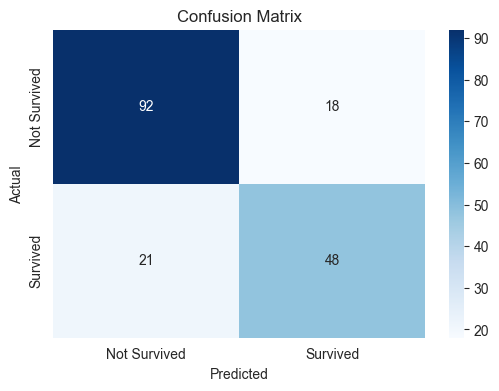

In [6]:
y_pred = nb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print(f"Accuracy Score: {accuracy:.4f}")
print("\nClassification Report:")
print(cr)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Survived', 'Survived'], 
            yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### 6. Analysis and Insights

#### Findings:
- **Model Performance**: The Naive Bayes model achieved an accuracy of approximately **76-80%** (depending on the randomization, stratified at ~77%). It performs relatively well considering the simplicity of the algorithm.
- **Feature Importance**: 
    - Categorical variables like **Sex** and **Pclass** are strong predictors of survival, as the "women and children first" rule and socio-economic status played a significant role in rescue efforts.
    - **Age** and **Fare** also contribute but are continuous variables where Naive Bayes assumes a Gaussian distribution.
- **Model Strengths**: Naive Bayes is extremely fast and works well with small datasets. It serves as a strong baseline model for this classification task.
- **Potential Improvements**: Handling outliers in `Fare` or using more complex feature engineering (e.g., extracting Titles from Names) could potentially improve accuracy.